In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


In [8]:
followup = pd.read_csv("../datasets/raw/SMART_C_Longitudinal_CKD_Benchmark_Dataset/followup.csv")
print("Dataset shape:", followup.shape)
print("\nColumns:")
print(followup.columns.tolist())

Dataset shape: (41800, 12)

Columns:
['usubjid', 'randfl', 'ittfl', 'trtfl', 'anl01fl', 'aval', 'base', 'paramcd', 'param', 'ady', 'avisitn', 'avisit']


In [9]:
print("First 5 rows:")
display(followup.head())

print("\nDataset information:")
followup.info()

print("\nMissing values:")
display(followup.isnull().sum())

print("\nAvailable visits:")
print(sorted(followup["avisitn"].dropna().unique()))

First 5 rows:


,usubjid,randfl,ittfl,trtfl,anl01fl,aval,base,paramcd,param,ady,avisitn,avisit
0,id0001,Y,Y,Y,Y,54,54,GFRBSCRT,GFR from Creatinine Adjusted for BSA (mL/min/1...,1,0,BASELINE
1,id0001,Y,Y,Y,Y,51,54,GFRBSCRT,GFR from Creatinine Adjusted for BSA (mL/min/1...,22,3,WEEK 3
2,id0001,Y,Y,Y,Y,61,54,GFRBSCRT,GFR from Creatinine Adjusted for BSA (mL/min/1...,91,13,WEEK 13
3,id0001,Y,Y,Y,Y,63,54,GFRBSCRT,GFR from Creatinine Adjusted for BSA (mL/min/1...,183,26,WEEK 26
4,id0001,Y,Y,Y,Y,53,54,GFRBSCRT,GFR from Creatinine Adjusted for BSA (mL/min/1...,362,52,WEEK 52



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 41800 entries, 0 to 41799
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   usubjid  41800 non-null  str  
 1   randfl   41800 non-null  str  
 2   ittfl    41800 non-null  str  
 3   trtfl    41800 non-null  str  
 4   anl01fl  41000 non-null  str  
 5   aval     41800 non-null  int64
 6   base     41800 non-null  int64
 7   paramcd  41800 non-null  str  
 8   param    41800 non-null  str  
 9   ady      41800 non-null  int64
 10  avisitn  41800 non-null  int64
 11  avisit   41800 non-null  str  
dtypes: int64(4), str(8)
memory usage: 6.9 MB

Missing values:


usubjid      0
randfl       0
ittfl        0
trtfl        0
anl01fl    800
aval         0
base         0
paramcd      0
param        0
ady          0
avisitn      0
avisit       0
dtype: int64


Available visits:
[0, 3, 13, 26, 52, 78, 104, 130, 156]


In [10]:
print("Original rows:", len(followup))

followup_clean = followup[
    followup["anl01fl"] == "Y"
].copy()

print("Rows after keeping analysis records:", len(followup_clean))

# Sort chronologically
followup_clean = followup_clean.sort_values(
    ["usubjid", "ady"]
).reset_index(drop=True)

print("\nDuplicate patient-visit combinations:")
duplicates = followup_clean.duplicated(
    subset=["usubjid", "avisitn"]
).sum()

print(duplicates)

Original rows: 41800
Rows after keeping analysis records: 41000

Duplicate patient-visit combinations:
0


In [11]:
egfr_data = followup_clean[
    ["usubjid", "avisitn", "aval"]
].copy()

# Convert eGFR to numeric
egfr_data["aval"] = pd.to_numeric(
    egfr_data["aval"],
    errors="coerce"
)

# Pivot visits into columns
progression_df = egfr_data.pivot_table(
    index="usubjid",
    columns="avisitn",
    values="aval",
    aggfunc="first"
).reset_index()

# Rename columns
progression_df = progression_df.rename(columns={
    0: "egfr_baseline",
    3: "egfr_w3",
    13: "egfr_w13",
    26: "egfr_w26",
    52: "egfr_w52",
    78: "egfr_w78",
    104: "egfr_w104",
    130: "egfr_w130",
    156: "egfr_w156"
})

print("Patient-level dataset shape:")
print(progression_df.shape)

display(progression_df.head())

Patient-level dataset shape:
(5000, 10)


avisitn,usubjid,egfr_baseline,egfr_w3,egfr_w13,egfr_w26,egfr_w52,egfr_w78,egfr_w104,egfr_w130,egfr_w156
0,id0001,54.0,51.0,61.0,63.0,53.0,47.0,37.0,58.0,59.0
1,id0002,27.0,60.0,50.0,NaN,44.0,53.0,53.0,NaN,55.0
2,id0003,50.0,42.0,NaN,52.0,52.0,55.0,58.0,61.0,42.0
3,id0004,47.0,42.0,45.0,46.0,50.0,52.0,50.0,31.0,NaN
4,id0005,75.0,52.0,62.0,43.0,53.0,42.0,33.0,32.0,55.0


In [12]:
required_columns = [
    "egfr_baseline",
    "egfr_w3",
    "egfr_w13",
    "egfr_w26",
    "egfr_w52",
    "egfr_w78",
    "egfr_w104"
]

progression_df = progression_df.dropna(
    subset=required_columns
).copy()

print("Final modeling cohort:", len(progression_df))
print("Required visits:", required_columns)

Final modeling cohort: 3263
Required visits: ['egfr_baseline', 'egfr_w3', 'egfr_w13', 'egfr_w26', 'egfr_w52', 'egfr_w78', 'egfr_w104']


In [14]:
# Basic changes
progression_df["egfr_change"] = (
    progression_df["egfr_w26"]
    - progression_df["egfr_baseline"]
)

progression_df["recent_change"] = (
    progression_df["egfr_w26"]
    - progression_df["egfr_w13"]
)

# Summary statistics
historical_values = progression_df[
    [
        "egfr_baseline",
        "egfr_w3",
        "egfr_w13",
        "egfr_w26"
    ]
]

progression_df["mean_egfr"] = historical_values.mean(axis=1)
progression_df["min_egfr"] = historical_values.min(axis=1)
progression_df["max_egfr"] = historical_values.max(axis=1)
progression_df["egfr_std"] = historical_values.std(axis=1)

# eGFR slopes
progression_df["slope_0_3"] = (
    progression_df["egfr_w3"]
    - progression_df["egfr_baseline"]
) / 3

progression_df["slope_3_13"] = (
    progression_df["egfr_w13"]
    - progression_df["egfr_w3"]
) / 10

progression_df["slope_13_26"] = (
    progression_df["egfr_w26"]
    - progression_df["egfr_w13"]
) / 13

progression_df["overall_slope"] = (
    progression_df["egfr_w26"]
    - progression_df["egfr_baseline"]
) / 26

progression_df["recent_slope"] = (
    progression_df["egfr_w26"]
    - progression_df["egfr_w13"]
) / 13

progression_df["slope_change_recent"] = (
    progression_df["recent_slope"]
    - progression_df["slope_3_13"]
)

print("Historical features created successfully.")

Historical features created successfully.


In [15]:
feature_cols = [
    "egfr_baseline",
    "egfr_w3",
    "egfr_w13",
    "egfr_w26",
    "egfr_change",
    "recent_change",
    "mean_egfr",
    "min_egfr",
    "max_egfr",
    "egfr_std",
    "slope_0_3",
    "slope_3_13",
    "slope_13_26",
    "overall_slope",
    "recent_slope",
    "slope_change_recent"
]

X = progression_df[feature_cols].copy()

print("Number of features:", len(feature_cols))
print("\nFeatures used:")
for i, feature in enumerate(feature_cols, start=1):
    print(f"{i}. {feature}")

Number of features: 16

Features used:
1. egfr_baseline
2. egfr_w3
3. egfr_w13
4. egfr_w26
5. egfr_change
6. recent_change
7. mean_egfr
8. min_egfr
9. max_egfr
10. egfr_std
11. slope_0_3
12. slope_3_13
13. slope_13_26
14. overall_slope
15. recent_slope
16. slope_change_recent


In [20]:
 #  CREATE PERSISTENT DECLINE TARGET
future_visits = [
    "egfr_w52",
    "egfr_w78",
    "egfr_w104"
]

future_pct_changes = pd.DataFrame(index=progression_df.index)

for visit in future_visits:
    future_pct_changes[f"{visit}_pct_change"] = (
        (progression_df[visit] - progression_df["egfr_w26"])
        / progression_df["egfr_w26"]
    ) * 100

display(future_pct_changes.head())

,egfr_w52_pct_change,egfr_w78_pct_change,egfr_w104_pct_change
0,-15.873016,-25.396825,-41.269841
3,8.695652,13.043478,8.695652
4,23.255814,-2.325581,-23.255814
5,48.936170,14.893617,21.276596
6,-22.807018,-12.280702,0.000000


In [21]:
# APPLY PERSISTENT DECLINE RULE
DECLINE_THRESHOLD = -5.0

decline_flags = (
    future_pct_changes <= DECLINE_THRESHOLD
)

progression_df["decline_count"] = decline_flags.sum(axis=1)

# Persistent decline = decline at 2 or more future visits
progression_df["persistent_decline"] = (
    progression_df["decline_count"] >= 2
).astype(int)

# Final target
y = progression_df["persistent_decline"]

print("Target distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print(
    y.value_counts(normalize=True).mul(100).round(2)
)

Target distribution:
persistent_decline
1    1636
0    1627
Name: count, dtype: int64

Target percentages:
persistent_decline
1    50.14
0    49.86
Name: proportion, dtype: float64


In [22]:
# VERIFY NO DATA LEAKAGE


print("Features used by the model:")
print(feature_cols)

future_columns = [
    "egfr_w52",
    "egfr_w78",
    "egfr_w104"
]

print("\nFuture columns used ONLY for target creation:")
print(future_columns)

print("\nFuture columns inside X:")
print(
    [col for col in future_columns if col in X.columns]
)

Features used by the model:
['egfr_baseline', 'egfr_w3', 'egfr_w13', 'egfr_w26', 'egfr_change', 'recent_change', 'mean_egfr', 'min_egfr', 'max_egfr', 'egfr_std', 'slope_0_3', 'slope_3_13', 'slope_13_26', 'overall_slope', 'recent_slope', 'slope_change_recent']

Future columns used ONLY for target creation:
['egfr_w52', 'egfr_w78', 'egfr_w104']

Future columns inside X:
[]


In [23]:
#  MODEL PIPELINE


model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [24]:
# 5-FOLD CROSS-VALIDATION

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("5-Fold Cross-Validation Results\n")

for metric in scoring.keys():
    scores = cv_results[f"test_{metric}"]
    
    print(
        f"{metric:20s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

5-Fold Cross-Validation Results

accuracy            : 0.8134 ± 0.0124
balanced_accuracy   : 0.8134 ± 0.0124
precision           : 0.8129 ± 0.0101
recall              : 0.8154 ± 0.0184
f1                  : 0.8141 ± 0.0133
roc_auc             : 0.8996 ± 0.0118


In [25]:

# OUT-OF-FOLD PREDICTIONS

y_pred = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    method="predict"
)

y_prob = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

print("Out-of-fold predictions generated.")

Out-of-fold predictions generated.


In [26]:
# ============================================
# CELL 16: FINAL CROSS-VALIDATED METRICS
# ============================================

accuracy = accuracy_score(y, y_pred)

balanced_acc = balanced_accuracy_score(
    y,
    y_pred
)

precision = precision_score(
    y,
    y_pred
)

recall = recall_score(
    y,
    y_pred
)

f1 = f1_score(
    y,
    y_pred
)

roc_auc = roc_auc_score(
    y,
    y_prob
)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        balanced_acc,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results["Score"] = results["Score"].round(4)

display(results)

,Metric,Score
0,Accuracy,0.8134
1,Balanced Accuracy,0.8134
2,Precision,0.8129
3,Recall,0.8154
4,F1 Score,0.8142
5,ROC-AUC,0.8995


In [29]:
print(classification_report(y,y_pred,target_names=["No Persistent Decline","Persistent Decline"]))

                       precision    recall  f1-score   support

No Persistent Decline       0.81      0.81      0.81      1627
   Persistent Decline       0.81      0.82      0.81      1636

             accuracy                           0.81      3263
            macro avg       0.81      0.81      0.81      3263
         weighted avg       0.81      0.81      0.81      3263



<Figure size 600x500 with 0 Axes>

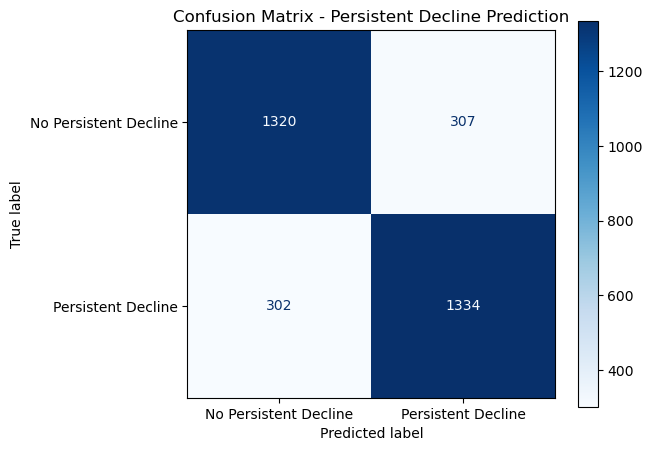

In [30]:
cm = confusion_matrix(y,y_pred)

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Persistent Decline","Persistent Decline"])

disp.plot(values_format="d",cmap="Blues")

plt.title("Confusion Matrix - Persistent Decline Prediction")
plt.tight_layout()
plt.show()

<Figure size 700x600 with 0 Axes>

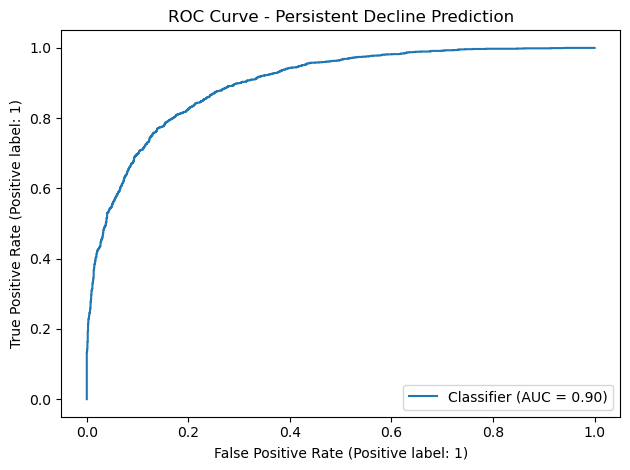

In [31]:
plt.figure(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y,
    y_prob
)

plt.title("ROC Curve - Persistent Decline Prediction")
plt.tight_layout()
plt.show()

<Figure size 700x600 with 0 Axes>

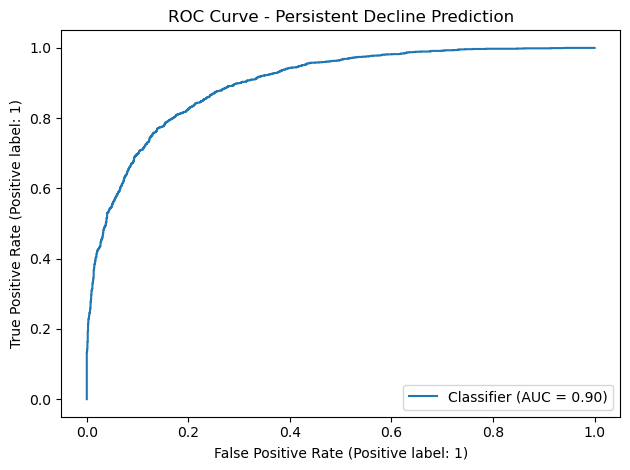

In [32]:
plt.figure(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y,
    y_prob
)

plt.title("ROC Curve - Persistent Decline Prediction")
plt.tight_layout()
plt.show()

In [34]:
final_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

final_model.fit(
    X,
    y
)

print("Final model trained successfully.")

Final model trained successfully.


In [35]:
model_artifact = {
    "model": final_model,
    "feature_cols": feature_cols,
    "decline_threshold_percent": 5.0,
    "persistent_decline_visits": [
        "W52",
        "W78",
        "W104"
    ],
    "required_decline_visits": 2
}

model_path = "../model/ckd_progression_model.pkl"

joblib.dump(
    model_artifact,
    model_path
)

print(f"Model saved successfully: {model_path}")

Model saved successfully: ../model/ckd_progression_model.pkl


In [37]:
# ============================================
# CELL 22: TEST SAVED MODEL
# ============================================

loaded_artifact = joblib.load(
    "../model/ckd_progression_model.pkl"
)

loaded_model = loaded_artifact["model"]

print("Model loaded successfully.")

print("\nStored features:")
print(loaded_artifact["feature_cols"])

print("\nPersistent decline rule:")
print(
    f"Decline threshold: "
    f"{loaded_artifact['decline_threshold_percent']}%"
)

print(
    "Required declining future visits:",
    loaded_artifact["required_decline_visits"]
)

Model loaded successfully.

Stored features:
['egfr_baseline', 'egfr_w3', 'egfr_w13', 'egfr_w26', 'egfr_change', 'recent_change', 'mean_egfr', 'min_egfr', 'max_egfr', 'egfr_std', 'slope_0_3', 'slope_3_13', 'slope_13_26', 'overall_slope', 'recent_slope', 'slope_change_recent']

Persistent decline rule:
Decline threshold: 5.0%
Required declining future visits: 2


In [38]:
# ============================================
# CELL 23: TEST ONE PATIENT
# ============================================

sample_patient = X.iloc[[0]]

prediction = loaded_model.predict(
    sample_patient
)[0]

probability = loaded_model.predict_proba(
    sample_patient
)[0, 1]

print("Prediction:", prediction)
print(f"Probability of persistent decline: {probability:.4f}")

if prediction == 1:
    print("Progression Outlook: Higher likelihood of persistent decline")
else:
    print("Progression Outlook: Lower likelihood of persistent decline")

Prediction: 1
Probability of persistent decline: 0.9886
Progression Outlook: Higher likelihood of persistent decline


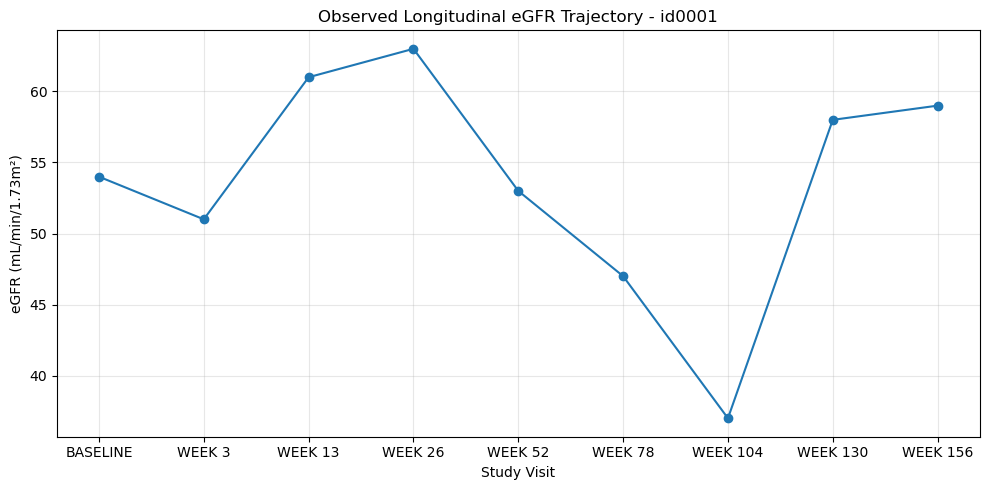

In [40]:
import matplotlib.pyplot as plt

# Pick one patient
patient_id = "id0001"

patient = followup_clean[
    followup_clean["usubjid"] == patient_id
].sort_values("ady")

plt.figure(figsize=(10, 5))

plt.plot(
    patient["avisit"],
    patient["aval"],
    marker="o"
)

plt.xlabel("Study Visit")
plt.ylabel("eGFR (mL/min/1.73m²)")
plt.title(f"Observed Longitudinal eGFR Trajectory - {patient_id}")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "fig7_observed_egfr_trajectory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()